# Wunder Predictorium — Solución completa

> **Autor:** Eder Tarifa &nbsp;·&nbsp; **Reto:** [Wunder Predictorium](https://wundernn.io/predictorium)
> **Métrica oficial:** *Weighted Pearson Correlation* (ponderada por `|y_true|`, predicciones recortadas a `[-6, 6]`).

Este cuaderno reúne **todas las iteraciones** del trabajo realizado para el reto:

1. **Análisis exploratorio de los datos** (LOB + trades).
2. **Feature engineering** sobre microestructura y dinámica del libro.
3. **Iteración 1 — Baselines clásicos**: Linear / Ridge / Random Forest / LightGBM.
4. **Iteración 2 — Modelos secuenciales DL básicos**: GRU / LSTM / Transformer causal.
5. **Iteración 3 — Modelos específicos / SOTA**: DeepLOB (Zhang 2019) y Mamba-2 (Dao 2024).
6. **Comparativa final y selección del mejor modelo**.

El cuaderno se apoya en el pipeline modular del paquete `src/` —cada modelo se entrena con
las mismas utilidades para que la comparativa sea justa y reproducible. **Cada modelo se
persiste en `experiments/<model>/<run_id>/`** (weights + métricas + plots + predicciones)
y la tabla acumulada se vuelca a `experiments/notebook_results.csv` tras cada iteración,
de modo que la información sobrevive al reinicio del kernel.

## 1 · Setup

Cargamos dependencias, fijamos semillas y un *toggle* `QUICK_MODE` que controla si entrenamos
en modo rápido (subset + pocos epochs, ~10–20 min) o completo (varias horas).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import gc
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
try:
    import psutil
    _PROC = psutil.Process()
    def mem_gb() -> float:
        return _PROC.memory_info().rss / 1024**3
except ImportError:
    def mem_gb() -> float:
        return float("nan")

# Silenciar el ruido de mamba-ssm (FutureWarnings de torch.cuda.amp).
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.modules.transformer")

# Asegurar que src/ está en el path cuando el notebook se ejecuta fuera de pytest.
ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(0)
torch.manual_seed(0)

print(f"PyTorch:   {torch.__version__}")
print(f"CUDA:      {torch.cuda.is_available()}", end="")
if torch.cuda.is_available():
    print(f"  ({torch.cuda.get_device_name(0)})")
else:
    print()
print(f"NumPy:     {np.__version__}")
print(f"Pandas:    {pd.__version__}")

PyTorch:   2.5.1+cu121
CUDA:      True  (NVIDIA GeForce RTX 4060 Laptop GPU)
NumPy:     2.4.4
Pandas:    3.0.3


In [2]:
# ⚙️  Toggle global. Cambia a False para entrenar al 100% (varias horas).
QUICK_MODE = False

# Subconjunto de secuencias usadas en modo rápido. Pon None para usar todas.
QUICK_N_TRAIN_SEQS = 800
QUICK_N_VAL_SEQS = 250

# Epochs por modelo DL en modo rápido. En modo completo se usan 20 epochs.
QUICK_EPOCHS = 4

# RandomForest escala mal (no usa sample_weight para early-stop). En LOB/HFT
# rara vez gana a LightGBM; ponlo a True si te crashea la RAM o tienes prisa.
SKIP_RF = False

# Salta toda la sección de modelos clásicos (linear/ridge/RF/lightgbm) y va
# directo a los DL. Útil cuando la construcción tabular en CPU no cabe en RAM.
SKIP_CLASSICAL = True

# Rolling features (mid_rmean_{5,20}, mid_rstd_{5,20}, vol_rmean_{5,20}) son
# costosas en memoria (groupby.transform). Las features 'spread', 'imbalance',
# 'momentum'... ya capturan la dinámica básica. Déjalo a False si tu RAM va justa.
WITH_ROLLING = False

# Procesar las features tabulares por chunks de N secuencias para acotar
# el peak de RAM. 200 es un buen compromiso (≈200·1000=200K filas por chunk).
TABULAR_CHUNK_SEQS = 200

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"QUICK_MODE={QUICK_MODE}  DEVICE={DEVICE}  SKIP_CLASSICAL={SKIP_CLASSICAL}  SKIP_RF={SKIP_RF}  WITH_ROLLING={WITH_ROLLING}")
print(f"RAM inicial: {mem_gb():.2f} GB")

QUICK_MODE=False  DEVICE=cuda  SKIP_CLASSICAL=True  SKIP_RF=False  WITH_ROLLING=False
RAM inicial: 0.57 GB


In [3]:
# API del pipeline.
from data import (
    load_train_valid, split_by_seq_ix, FeatureScaler,
    FEATURE_COLS, TARGET_COLS, SEQ_LEN, WARMUP_STEPS, N_FEATURES, N_TARGETS,
    sequences_from_dataframe, SequenceDataset,
    build_tabular_features, make_tabular_dataset,
)
from data.constants import (
    BID_PRICES, ASK_PRICES, BID_VOLUMES, ASK_VOLUMES,
    TRADE_PRICES, TRADE_VOLUMES,
)
from feature_engineering import add_engineered_features, ENGINEERED_FEATURES
from metrics import (
    summary, weighted_pearson_per_target, per_sequence_weighted_pearson,
)
from losses import build_loss
from models import get_model_class, list_models, MODEL_REGISTRY
from training import TrainerConfig, train_classical_model, train_sequence_model
from training.classical_trainer import ClassicalTrainerConfig
from evaluation import Evaluator, write_report, make_run_id

print("modelos registrados:")
for kind in ("classical", "sequence"):
    print(f"  [{kind}] {', '.join(list_models(kind))}")

modelos registrados:
  [classical] lightgbm, linear, random_forest, ridge
  [sequence] deeplob, gru, lstm, mamba2, transformer


## 2 · Análisis exploratorio de los datos (EDA)

### Origen de los datos

El reto provee dos parquet ya pre-procesados en `competition_package/datasets/`:

- `train.parquet` — 10 721 secuencias.
- `valid.parquet` — 1 444 secuencias.

Cada secuencia tiene **1000 pasos** independientes; los primeros 99 son *warm-up* (no se evalúan).
Las columnas son 32 features anonimizadas del LOB + trades, más las dos targets (`t0`, `t1`).

In [4]:
# Carga inteligente: si QUICK_MODE, leemos del parquet SOLO las secuencias
# que vamos a usar (filter-pushdown de pyarrow). Saltamos ~92% de la RAM
# vs cargar las 10 721 secuencias completas y luego subsettar.
from data import load_subset

if QUICK_MODE:
    print(f"Cargando subset directamente del parquet ({QUICK_N_TRAIN_SEQS} train + {QUICK_N_VAL_SEQS} val seqs)...")
    train_df = load_subset(
        "competition_package/datasets/train.parquet",
        n_seqs=QUICK_N_TRAIN_SEQS, seed=SEED,
    )
    valid_df = load_subset(
        "competition_package/datasets/valid.parquet",
        n_seqs=QUICK_N_VAL_SEQS, seed=SEED,
    )
else:
    print("Cargando los parquets completos...")
    train_df, valid_df = load_train_valid()

print(f"train: {len(train_df):,} filas · {train_df['seq_ix'].nunique():,} secuencias")
print(f"valid: {len(valid_df):,} filas · {valid_df['seq_ix'].nunique():,} secuencias")
print(f"RAM tras carga: {mem_gb():.2f} GB")
train_df.head()

Cargando los parquets completos...
train: 10,721,000 filas · 10,721 secuencias
valid: 1,444,000 filas · 1,444 secuencias
RAM tras carga: 3.59 GB


,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,False,1.077446,-0.710366,0.373591,0.835558,0.050204,-0.139710,1.367384,...,-0.031078,-0.053527,-0.475214,-0.410787,0.805692,0.516635,-0.368215,-0.503497,-0.564226,1.864018
1,0,1,False,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.354714,...,0.950145,-0.083598,-0.604252,-0.703991,-1.925171,1.252957,-1.563974,-1.929990,-0.239079,2.168844
2,0,2,False,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.870266,...,-0.168259,1.632066,-0.178565,0.121240,1.377339,1.803970,-0.402838,1.042579,2.237778,2.459723
3,0,3,False,0.955471,-1.486537,0.230353,0.676854,-0.262686,-0.366873,2.011996,...,-0.426942,-0.743530,0.680013,1.394857,0.785266,1.424660,1.258192,0.914074,1.998699,2.272444
4,0,4,False,1.025123,-0.832006,0.317650,0.759677,-0.062770,-0.230353,2.174650,...,0.195700,0.293986,0.494971,0.267884,-1.315502,1.775372,1.302424,1.355667,1.998699,2.324245


In [5]:
# Tamaño en memoria y dtypes — confirmamos que load_dataset hace el downcast a float32.
train_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 10721000 entries, 0 to 10720999
Data columns (total 37 columns):
 #   Column           Dtype  
---  ------           -----  
 0   seq_ix           int64  
 1   step_in_seq      int64  
 2   need_prediction  bool   
 3   p0               float32
 4   p1               float32
 5   p2               float32
 6   p3               float32
 7   p4               float32
 8   p5               float32
 9   p6               float32
 10  p7               float32
 11  p8               float32
 12  p9               float32
 13  p10              float32
 14  p11              float32
 15  v0               float32
 16  v1               float32
 17  v2               float32
 18  v3               float32
 19  v4               float32
 20  v5               float32
 21  v6               float32
 22  v7               float32
 23  v8               float32
 24  v9               float32
 25  v10              float32
 26  v11              float32
 27  dp0              floa

### Distribución de las targets

Las dos targets son indicadores anonimizados de movimientos futuros. La métrica pondera
por `|y_true|`, así que la mayor parte del *score* viene de los pasos con target grande.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, tgt in zip(axes, TARGET_COLS):
    sns.histplot(train_df[tgt], bins=120, kde=False, ax=ax, color="steelblue")
    ax.set_xlim(-6.5, 6.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{tgt}  ·  mean={train_df[tgt].mean():+.3f}  std={train_df[tgt].std():.3f}")
    ax.set_xlabel(tgt)
fig.suptitle("Distribución de las targets en train (recortado a [-6.5, 6.5])")
fig.tight_layout()
plt.show()

# Cuánta proporción de pasos puntúa.
pct_scored = train_df["need_prediction"].mean() * 100
print(f"% de filas evaluadas (need_prediction=True): {pct_scored:.1f}%")
print(f"correlación entre t0 y t1 (Pearson): {train_df[['t0','t1']].corr().iloc[0,1]:+.3f}")

### Ejemplo: una secuencia completa

Visualizar una sola secuencia ayuda a entender el régimen temporal de los datos.
El mid-price es `(p0 + p6) / 2` (mejor bid + mejor ask) y se construye on-the-fly aquí.

In [ ]:
sample_seq_id = int(train_df["seq_ix"].iloc[0])
seq = train_df[train_df["seq_ix"] == sample_seq_id]
mid = (seq["p0"] + seq["p6"]) / 2
spread = seq["p6"] - seq["p0"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(seq["step_in_seq"], mid, color="tab:blue")
axes[0].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray", label="warm-up")
axes[0].set_ylabel("mid-price")
axes[0].set_title(f"seq_ix={sample_seq_id}")
axes[0].legend(loc="upper left")

axes[1].plot(seq["step_in_seq"], spread, color="tab:orange")
axes[1].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray")
axes[1].set_ylabel("spread (p6 - p0)")

axes[2].plot(seq["step_in_seq"], seq["t0"], label="t0", alpha=0.75)
axes[2].plot(seq["step_in_seq"], seq["t1"], label="t1", alpha=0.75)
axes[2].axvspan(0, WARMUP_STEPS, alpha=0.15, color="gray")
axes[2].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[2].set_ylabel("targets")
axes[2].set_xlabel("step in seq")
axes[2].legend(loc="upper right")
fig.suptitle("Anatomía de una secuencia: mid-price, spread y targets")
fig.tight_layout()
plt.show()

### Estadísticos de los features

Resumimos en un solo grid las primeras filas + un boxplot por grupo. Los features están
anonimizados pero conservan la estructura típica de LOB (precios escalonados, volúmenes
positivos con cola larga).

In [ ]:
groups = {
    "bid prices (p0..p5)": BID_PRICES,
    "ask prices (p6..p11)": ASK_PRICES,
    "bid volumes (v0..v5)": BID_VOLUMES,
    "ask volumes (v6..v11)": ASK_VOLUMES,
    "trade prices (dp0..dp3)": TRADE_PRICES,
    "trade volumes (dv0..dv3)": TRADE_VOLUMES,
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (title, cols) in zip(axes.flat, groups.items()):
    data = train_df[cols].melt(value_name="value", var_name="feature")
    sns.boxplot(data=data, x="feature", y="value", ax=ax, fliersize=0.5, color="steelblue")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel(None)
fig.suptitle("Distribución de los 32 features brutos (cajas y bigotes)")
fig.tight_layout()
plt.show()

### Correlación entre features y targets

Mapa de calor: cada feature contra `t0` y `t1`. Esperamos correlaciones bajas (SNR
microestructural típico) pero algunos features dominan: spread, desequilibrio de
volumen, momentum del mid…

In [ ]:
# Calcular correlación solo sobre filas evaluadas (need_prediction=True) — coincide con la métrica.
scored = train_df[train_df["need_prediction"]]
corr_block = scored[FEATURE_COLS + TARGET_COLS].corr().loc[FEATURE_COLS, TARGET_COLS]
plt.figure(figsize=(5, 8))
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=True, fmt="+.2f",
            cbar_kws={"label": "Pearson"})
plt.title("Correlación lineal feature ↔ target (solo filas evaluadas)")
plt.tight_layout()
plt.show()

## 3 · Feature engineering

El paquete `feature_engineering` añade 12 features derivadas:

* **Microestructura**: `spread`, `mid_price`, `bid_ask_volume_imbalance`, 6 niveles de
  `depth_imbalance_level_k`.
* **Dinámica**: `price_momentum`, `volume_momentum`, `bid_ask_momentum_diff`.

El pipeline (`data.tabular.build_tabular_features`) adicionalmente añade *rolling stats*
multi-ventana (5 y 20 pasos) sobre el mid-price y el volumen total. Todas las
operaciones respetan los límites de secuencia vía `groupby('seq_ix')`.

In [5]:
# Mostrar las features ingenieradas en una muestra pequeña.
sample_ids = train_df["seq_ix"].unique()[:30]
sample = train_df[train_df["seq_ix"].isin(sample_ids)].copy()
sample_eng = add_engineered_features(sample)

new_cols = [c for c in sample_eng.columns if c not in sample.columns]
print(f"features añadidas: {len(new_cols)}")
sample_eng[new_cols].describe().T[["mean", "std", "min", "50%", "max"]]

features añadidas: 12


,mean,std,min,50%,max
spread,0.119798,0.445579,-2.132681,0.151706,2.218807
mid_price,1.507250,0.438900,0.899835,1.461110,3.409179
bid_ask_volume_imbalance,0.054388,0.789140,-1.000000,0.159941,1.000000
depth_imbalance_level_0,0.157561,0.683637,-1.000000,0.215622,1.000000
depth_imbalance_level_1,0.134868,0.819661,-1.000000,0.238078,1.000000
depth_imbalance_level_2,0.119221,0.612334,-1.000000,0.092843,1.000000
depth_imbalance_level_3,0.256886,0.865725,-1.000000,0.869303,1.000000
depth_imbalance_level_4,0.070360,0.738459,-1.000000,0.009373,1.000000
depth_imbalance_level_5,-0.291988,0.684440,-1.000000,-0.436294,1.000000
price_momentum,0.000025,0.348952,-1.847658,0.000000,1.894773


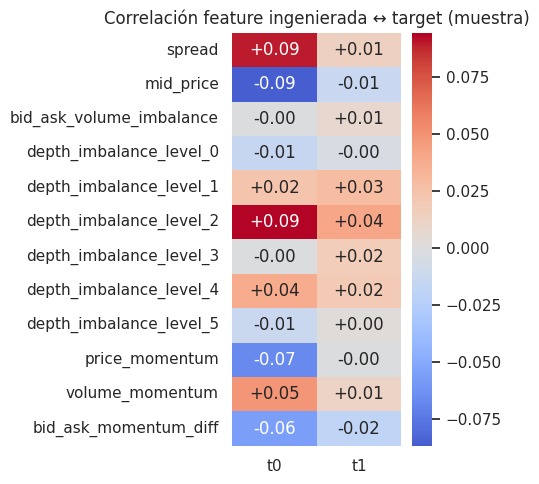

In [6]:
# Correlación de las features ingenieradas con los targets (mejor proxy de utilidad).
scored_sample = sample_eng[sample_eng["need_prediction"]]
corr_eng = scored_sample[new_cols + TARGET_COLS].corr().loc[new_cols, TARGET_COLS]
plt.figure(figsize=(5, 5))
sns.heatmap(corr_eng, cmap="coolwarm", center=0, annot=True, fmt="+.2f")
plt.title("Correlación feature ingenierada ↔ target (muestra)")
plt.tight_layout()
plt.show()

## 4 · Estrategia de modelado

Probaremos 9 modelos en tres rondas. Las claves son:

* **Splits por `seq_ix`** — usamos el `valid.parquet` oficial; jamás partimos filas dentro de una secuencia.
* **Loss alineado con la métrica** — `Weighted Pearson Loss` para los modelos DL (con `clamp(-6, 6)` interno) y `sample_weight = |y_true|` para los clásicos.
* **Evaluación** — `weighted_pearson` por target + media (idéntico al scorer oficial).
* **Reproducibilidad** — semilla 0 en todos los `np.random` / `torch.manual_seed` y, donde aplique, en los estimadores sklearn.

| # | Familia | Modelo | Notas |
|---|---------|--------|-------|
| 1 | Clásico | `linear` | Regresión lineal con `sample_weight=|y|`. |
| 2 | Clásico | `ridge` | L2-regularizado. |
| 3 | Clásico | `random_forest` | Sin escalado. |
| 4 | Clásico | `lightgbm` | Early-stopping sobre weighted Pearson. |
| 5 | DL | `gru` | GRU 2-layer, streamable. |
| 6 | DL | `lstm` | LSTM 2-layer, streamable. |
| 7 | DL | `transformer` | Pre-LN encoder + causal mask. |
| 8 | DL/SOTA | `deeplob` | Zhang 2019 (CNN+LSTM), adaptado a regresión. |
| 9 | DL/SOTA | `mamba2` | Selective SSM (kernels nativos CUDA cuando disponibles). |

In [7]:
# Ya no hace falta volver a sub-muestrear — load_subset lo hizo en la carga.
# Renombramos simplemente para mantener la semántica de "datos efectivos".
train_use = train_df
val_use   = valid_df
del train_df, valid_df
gc.collect()

print(f"train_use: {train_use['seq_ix'].nunique()} secuencias · {len(train_use):,} filas")
print(f"val_use:   {val_use['seq_ix'].nunique()} secuencias · {len(val_use):,} filas")
print(f"RAM tras subset: {mem_gb():.2f} GB")

# Scaler — se usa para los modelos DL (no para clásicos).
scaler = FeatureScaler(mode="standard").fit(train_use, FEATURE_COLS)

# Resultados acumulados — se rellenan en las siguientes secciones.
results: list[dict] = []

# Persistencia entre celdas: cada iteración añade su fila aquí.
EXPERIMENTS_ROOT = Path("experiments")
EXPERIMENTS_ROOT.mkdir(exist_ok=True)
NOTEBOOK_RESULTS_CSV = EXPERIMENTS_ROOT / "notebook_results.csv"

def _flush_results():
    """Vuelca la tabla `results` a CSV tras cada iteración."""
    if results:
        pd.DataFrame(results).to_csv(NOTEBOOK_RESULTS_CSV, index=False)
;

train_use: 10721 secuencias · 10,721,000 filas
val_use:   1444 secuencias · 1,444,000 filas
RAM tras subset: 3.59 GB


''

## 5 · Iteración 1 — Baselines clásicos

Estos modelos usan los 32 features brutos **+ las 12 ingenieradas + rolling stats (5, 20)**.
Cada modelo se ajusta por target (one-vs-rest) con `sample_weight = |y_true|`. Tras el
entrenamiento, cada run se persiste en `experiments/<model>/<run_id>/` con `model.joblib`,
`config.yaml`, `metrics.json`, `predictions.parquet`, `scatter.png` y `per_seq_corr.png`.

**Optimización de RAM**: construimos las features tabulares **una sola vez** y las
reutilizamos en los 4 modelos (antes se recomputaban en cada `run_classical`, ×4).

In [8]:
# === Construir features tabulares por CHUNKS (acotamos el peak de RAM) ===
# En vez de transformar el DataFrame entero (que copia ~3 GB transitorios),
# procesamos `TABULAR_CHUNK_SEQS` secuencias a la vez y concatenamos los ndarrays
# finales. Cada chunk libera sus copias intermedias en gc.collect().
from metrics.pearson import _weighted_pearson_scalar  # type: ignore
from evaluation.evaluator import EvalResult
from dataclasses import replace as _dc_replace

ROLLING_WINDOWS = (5, 20) if WITH_ROLLING else ()

if SKIP_CLASSICAL:
    print("⊘ Saltando construcción tabular (SKIP_CLASSICAL=True).")
    train_data = val_data = feature_cols = None

def _build_tabular_arrays_chunked(df, *, chunk_seqs, with_engineered, rolling_windows):
    unique_seqs = df["seq_ix"].unique()
    n_chunks = max(1, len(unique_seqs) // chunk_seqs + bool(len(unique_seqs) % chunk_seqs))
    chunks_X, chunks_y, chunks_w, chunks_sid, chunks_step = [], [], [], [], []
    feature_cols_final = None
    for i, sub_ids in enumerate(np.array_split(unique_seqs, n_chunks)):
        chunk_df = df[df["seq_ix"].isin(sub_ids)]
        tab, cols = build_tabular_features(
            chunk_df, with_engineered=with_engineered, rolling_windows=rolling_windows,
        )
        ds = make_tabular_dataset(tab, cols, only_scored_rows=True, drop_warmup=True)
        feature_cols_final = cols
        chunks_X.append(ds.X);    chunks_y.append(ds.y)
        chunks_w.append(ds.weights); chunks_sid.append(ds.seq_ids); chunks_step.append(ds.step_ids)
        del chunk_df, tab, ds
        gc.collect()
        if (i + 1) % 5 == 0 or i + 1 == n_chunks:
            print(f"    chunk {i+1}/{n_chunks}  ·  RAM {mem_gb():.2f} GB")
    return (
        np.concatenate(chunks_X), np.concatenate(chunks_y),
        np.concatenate(chunks_w), np.concatenate(chunks_sid),
        np.concatenate(chunks_step), feature_cols_final,
    )

if not SKIP_CLASSICAL:
    t0 = time.time()
    print("Building train tabular cache (chunked)...")
    X_tr, y_tr, w_tr, sid_tr, step_tr, feature_cols = _build_tabular_arrays_chunked(
        train_use, chunk_seqs=TABULAR_CHUNK_SEQS, with_engineered=True,
        rolling_windows=ROLLING_WINDOWS,
    )
    print("Building val tabular cache (chunked)...")
    X_va, y_va, w_va, sid_va, step_va, _ = _build_tabular_arrays_chunked(
        val_use, chunk_seqs=TABULAR_CHUNK_SEQS, with_engineered=True,
        rolling_windows=ROLLING_WINDOWS,
    )

    # Re-empaquetar en los TabularDataset dataclass para compatibilidad con el resto.
    from data.tabular import TabularDataset
    train_data = TabularDataset(X=X_tr, y=y_tr, weights=w_tr, seq_ids=sid_tr, step_ids=step_tr,
                                feature_names=feature_cols, target_names=list(TARGET_COLS))
    val_data   = TabularDataset(X=X_va, y=y_va, weights=w_va, seq_ids=sid_va, step_ids=step_va,
                                feature_names=feature_cols, target_names=list(TARGET_COLS))
    del X_tr, y_tr, w_tr, sid_tr, step_tr, X_va, y_va, w_va, sid_va, step_va
    gc.collect()

    print(f"\nfeatures:   {len(feature_cols)}  ({'con' if WITH_ROLLING else 'sin'} rolling)")
    print(f"train_data: X{tuple(train_data.X.shape)}  y{tuple(train_data.y.shape)}")
    print(f"val_data:   X{tuple(val_data.X.shape)}   y{tuple(val_data.y.shape)}")
    print(f"RAM tras tabular cache: {mem_gb():.2f} GB  ·  build en {time.time()-t0:.1f}s")

⊘ Saltando construcción tabular (SKIP_CLASSICAL=True).


In [9]:
def run_classical(name: str, params: dict | None = None):
    ModelCls, kind = get_model_class(name)
    assert kind == "classical", f"{name} no es clásico"
    model = ModelCls(params or {})

    t0 = time.time()
    model.fit(
        train_data.X, train_data.y,
        sample_weight=train_data.weights,
        eval_set=(val_data.X, val_data.y),
        feature_names=feature_cols,
        target_names=val_data.target_names,
    )
    fit_seconds = time.time() - t0

    val_pred = model.predict(val_data.X)
    metrics_dict = summary(val_data.y, val_pred)
    per_seq = {
        int(sid): _weighted_pearson_scalar(val_data.y[val_data.seq_ids == sid],
                                            val_pred[val_data.seq_ids == sid])
        for sid in np.unique(val_data.seq_ids)
    }
    val_eval = EvalResult(
        metrics=metrics_dict, predictions=val_pred, targets=val_data.y,
        seq_ids=val_data.seq_ids, step_ids=val_data.step_ids,
        per_sequence_corr=per_seq,
    )
    wp = metrics_dict["weighted_pearson"]
    per = metrics_dict["per_target"]

    # Persistir el run a disco.
    run_id = make_run_id(name)
    run_dir = EXPERIMENTS_ROOT / name / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    model.save(run_dir / "model.joblib")
    write_report(
        run_dir=run_dir,
        config={"model": {"name": name, "params": params or {}},
                "classical": {"rolling_windows": list(ROLLING_WINDOWS)},
                "quick_mode": QUICK_MODE},
        history=None,
        val_eval=val_eval,
        extra_meta={"kind": "classical", "model_name": name,
                    "feature_columns": feature_cols,
                    "fit_seconds": fit_seconds,
                    "wallclock_seconds": fit_seconds},
    )

    row = {
        "model": name, "kind": "classical",
        "val_weighted_pearson": wp,
        "val_t0": per["t0"], "val_t1": per["t1"],
        "fit_seconds": fit_seconds,
        "n_features": len(feature_cols),
        "wallclock_seconds": fit_seconds,
        "run_dir": str(run_dir),
    }
    results.append(row)
    _flush_results()
    print(f"  ✓ {name:<14} corr={wp:+.4f}  (t0={per['t0']:+.4f}  t1={per['t1']:+.4f})  in {fit_seconds:5.1f}s  →  {run_dir}")
    return model, val_eval
;

''

In [10]:
if SKIP_CLASSICAL:
    print("⊘ Sección clásicos saltada (SKIP_CLASSICAL=True). Pasa directamente a la sec. 6 (DL).")
    linear_model = ridge_model = lgb_model = None
    linear_eval = ridge_eval = lgb_eval = None
    if 'rf_model' not in dir(): rf_model = None
    if 'rf_eval' not in dir():  rf_eval = None
else:
    # Linear (un punto de partida — diagnóstico de señal lineal).
    linear_model, linear_eval = run_classical("linear")

⊘ Sección clásicos saltada (SKIP_CLASSICAL=True). Pasa directamente a la sec. 6 (DL).


In [11]:
if not SKIP_CLASSICAL:
    # Ridge — versión regularizada.
    ridge_model, ridge_eval = run_classical("ridge", {"alpha": 1.0})

In [12]:
# Random Forest — modelo no-lineal.
#
# ⚠️  RF de sklearn no soporta early-stopping con la métrica del reto y escala mal
# con muchas filas + alta profundidad. En LOB/HFT casi nunca gana a LightGBM (ver
# writeups Optiver, JPX, G-Research). Por eso usamos hiperparámetros conservadores
# incluso en modo completo: lo importante es tenerlo en la comparativa, no batirlo.
#
# Tiempo aproximado en CPU 8-core:
#   QUICK_MODE=True   → ~3-5 min  (40 árboles × depth 8 sobre 1.35M filas)
#   QUICK_MODE=False  → ~30-60 min  (100 árboles × depth 10 sobre 9.6M filas)
#
# Si tienes prisa o poca RAM, pon SKIP_RF=True arriba.
if SKIP_CLASSICAL or SKIP_RF:
    if not SKIP_CLASSICAL:
        print("  ⊘  random_forest saltado (SKIP_RF=True)")
else:
    rf_params = (
        {  # QUICK_MODE
            "n_estimators": 40, "max_depth": 8, "min_samples_leaf": 500,
            "max_features": 0.5, "n_jobs": -1, "random_state": SEED,
        }
        if QUICK_MODE else
        {  # full mode — conservador a propósito
            "n_estimators": 100, "max_depth": 10, "min_samples_leaf": 500,
            "max_features": 0.5, "n_jobs": -1, "random_state": SEED,
        }
    )
    rf_model, rf_eval = run_classical("random_forest", rf_params)

In [13]:
if not SKIP_CLASSICAL:
    # LightGBM — históricamente el rey en Kaggles de microestructura.
    lgb_model, lgb_eval = run_classical(
        "lightgbm",
        {
            "params": {
                "objective": "regression", "metric": "None",
                "learning_rate": 0.05, "num_leaves": 63,
                "min_data_in_leaf": 100, "feature_fraction": 0.8,
                "bagging_fraction": 0.8, "bagging_freq": 5,
                "lambda_l2": 1.0, "verbose": -1,
            },
            "num_boost_round": 400 if QUICK_MODE else 3000,
            "early_stopping_rounds": 50,
            "log_period": 100000,
        },
    )

    # Liberar la cache tabular: los clásicos ya están entrenados y persistidos.
    del train_data, val_data
    gc.collect()
    print(f"RAM tras liberar tabular cache: {mem_gb():.2f} GB")

## 6 · Iteración 2 — Modelos secuenciales DL básicos

Los DL ven la secuencia completa de 1000 pasos. El loss enmascara el warm-up (pasos < 99).
En modo rápido entrenamos 4 epochs con d_hidden 64 para iterar cómodo; en modo completo,
los hiperparámetros se mueven a los valores de `configs/models/<name>.yaml`.

In [14]:
# Construir datasets una sola vez (reutilizables para todos los modelos secuenciales).
# Escalamos justo ahora (mantenemos los DataFrames escalados solo durante la sección DL).
train_scaled = scaler.transform(train_use)
val_scaled   = scaler.transform(val_use)
# Ya no necesitamos train_use / val_use crudos: el evaluator de DL trabaja sobre los escalados.
del train_use, val_use
gc.collect()

train_arr = sequences_from_dataframe(train_scaled)
val_arr   = sequences_from_dataframe(val_scaled)
train_ds  = SequenceDataset(train_arr)
val_ds    = SequenceDataset(val_arr)
# Las arrays están ya copiadas dentro del Dataset; podemos soltar las versiones intermedias.
del train_arr
gc.collect()

print(f"train_ds: {len(train_ds)} secuencias  ·  val_ds: {len(val_ds)} secuencias")
print(f"RAM tras montar sequence datasets: {mem_gb():.2f} GB")

train_ds: 10721 secuencias  ·  val_ds: 1444 secuencias
RAM tras montar sequence datasets: 6.88 GB


In [15]:
def run_sequence(name: str, params: dict | None = None, *, trainer_overrides: dict | None = None):
    ModelCls, kind = get_model_class(name)
    assert kind == "sequence", f"{name} no es secuencial"
    params = {**(params or {}), "n_features": N_FEATURES, "n_targets": N_TARGETS}
    model = ModelCls(params)

    cfg_dict = dict(
        epochs=QUICK_EPOCHS if QUICK_MODE else 20,
        batch_size=16 if QUICK_MODE else 32,
        learning_rate=1e-3,
        weight_decay=1e-4,
        warmup_epochs=0 if QUICK_MODE else 1,
        grad_clip=1.0,
        eval_every=1,
        device=DEVICE,
        amp=(DEVICE == "cuda"),
        seed=SEED,
        loss_name="weighted_pearson",
        early_stopping_patience=2 if QUICK_MODE else 5,
        num_workers=0,
        pin_memory=(DEVICE == "cuda"),
    )
    cfg_dict.update(trainer_overrides or {})
    trainer_cfg = TrainerConfig(**cfg_dict)

    t0 = time.time()
    info = train_sequence_model(model, train_ds, val_ds, trainer_cfg)
    elapsed = time.time() - t0

    ev = Evaluator()
    val_eval = ev.run_sequence_model(model, val_scaled, device=trainer_cfg.resolve_device())
    wp = val_eval.metrics["weighted_pearson"]
    per = val_eval.metrics["per_target"]

    # Persistir el run a disco (weights + métricas + plots + history).
    run_id = make_run_id(name)
    run_dir = EXPERIMENTS_ROOT / name / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    model.save(run_dir / "model.pt")
    write_report(
        run_dir=run_dir,
        config={"model": {"name": name, "params": params},
                "training": cfg_dict,
                "quick_mode": QUICK_MODE},
        history=info["history"],
        val_eval=val_eval,
        extra_meta={"kind": "sequence", "model_name": name,
                    "best_score_during_train": float(info["best_score"]),
                    "wallclock_seconds": elapsed},
    )

    row = {
        "model": name,
        "kind": "sequence",
        "val_weighted_pearson": wp,
        "val_t0": per["t0"],
        "val_t1": per["t1"],
        "fit_seconds": elapsed,
        "epochs_done": len(info["history"]),
        "best_score_during_train": info["best_score"],
        "wallclock_seconds": elapsed,
        "run_dir": str(run_dir),
    }
    results.append(row)
    _flush_results()
    print(f"  ✓ {name:<14} corr={wp:+.4f}  (t0={per['t0']:+.4f}  t1={per['t1']:+.4f})  epochs={len(info['history'])}  in {elapsed:5.1f}s  →  {run_dir}")
    return model, info, val_eval
;

''

In [16]:
gru_model, gru_info, gru_eval = run_sequence(
    "gru",
    {"hidden_size": 64 if QUICK_MODE else 128, "num_layers": 2, "dropout": 0.1},
)

epoch   1 | loss 0.83017 | val_corr +0.2202 | best +0.2202 | lr 1.00e-03 | 9.7s  *

epoch   2 | loss 0.75160 | val_corr +0.2481 | best +0.2481 | lr 9.93e-04 | 6.5s  *

epoch   3 | loss 0.73308 | val_corr +0.2510 | best +0.2510 | lr 9.73e-04 | 7.5s  *

epoch   4 | loss 0.72357 | val_corr +0.2523 | best +0.2523 | lr 9.40e-04 | 7.7s  *

epoch   5 | loss 0.71497 | val_corr +0.2599 | best +0.2599 | lr 8.95e-04 | 7.3s  *

...

epoch   9 | loss 0.65192 | val_corr +0.2214 | best +0.2604 | lr 6.23e-04 | 7.8s

epoch  10 | loss 0.62352 | val_corr +0.2171 | best +0.2604 | lr 5.41e-04 | 5.5s

epoch  11 | loss 0.59352 | val_corr +0.2154 | best +0.2604 | lr 4.59e-04 | 7.3s

early stopping at epoch 11 (no improvement in 5 epochs)

  ✓ gru            corr=+0.2604  (t0=+0.3872  t1=+0.1335)  epochs=11  in  82.3s  →  experiments/gru/gru__20260516-171801


In [17]:
lstm_model, lstm_info, lstm_eval = run_sequence(
    "lstm",
    {"hidden_size": 64 if QUICK_MODE else 128, "num_layers": 2, "dropout": 0.1},
)

epoch   1 | loss 0.83191 | val_corr +0.2236 | best +0.2236 | lr 1.00e-03 | 8.0s  *

epoch   2 | loss 0.75090 | val_corr +0.2484 | best +0.2484 | lr 9.93e-04 | 5.9s  *

epoch   3 | loss 0.73713 | val_corr +0.2477 | best +0.2484 | lr 9.73e-04 | 7.9s

epoch   4 | loss 0.72932 | val_corr +0.2377 | best +0.2484 | lr 9.40e-04 | 7.8s

epoch   5 | loss 0.72276 | val_corr +0.2545 | best +0.2545 | lr 8.95e-04 | 7.8s  *

...

epoch   9 | loss 0.68718 | val_corr +0.2420 | best +0.2662 | lr 6.23e-04 | 7.9s

epoch  10 | loss 0.67172 | val_corr +0.2410 | best +0.2662 | lr 5.41e-04 | 6.0s

epoch  11 | loss 0.65249 | val_corr +0.2327 | best +0.2662 | lr 4.59e-04 | 8.1s

early stopping at epoch 11 (no improvement in 5 epochs)

  ✓ lstm           corr=+0.2662  (t0=+0.3969  t1=+0.1354)  epochs=11  in  81.1s  →  experiments/lstm/lstm__20260516-171935


In [18]:
transformer_model, tfm_info, tfm_eval = run_sequence(
    "transformer",
    {
        "d_model": 64 if QUICK_MODE else 128,
        "nhead": 4,
        "num_layers": 2 if QUICK_MODE else 3,
        "dim_feedforward": 128 if QUICK_MODE else 256,
        "dropout": 0.1,
        "max_len": 1024,
    },
)

epoch   1 | loss 0.82738 | val_corr +0.2070 | best +0.2070 | lr 1.00e-03 | 13.4s  *

epoch   2 | loss 0.77918 | val_corr +0.2166 | best +0.2166 | lr 9.93e-04 | 14.8s  *

epoch   3 | loss 0.76411 | val_corr +0.2121 | best +0.2166 | lr 9.73e-04 | 13.2s

epoch   4 | loss 0.75745 | val_corr +0.2150 | best +0.2166 | lr 9.40e-04 | 14.9s

epoch   5 | loss 0.74766 | val_corr +0.2253 | best +0.2253 | lr 8.95e-04 | 13.1s  *

...

epoch  11 | loss 0.68335 | val_corr +0.2097 | best +0.2339 | lr 4.59e-04 | 15.3s

epoch  12 | loss 0.66195 | val_corr +0.2162 | best +0.2339 | lr 3.77e-04 | 13.3s

epoch  13 | loss 0.63963 | val_corr +0.2019 | best +0.2339 | lr 2.99e-04 | 15.3s

early stopping at epoch 13 (no improvement in 5 epochs)

  ✓ transformer    corr=+0.2339  (t0=+0.3460  t1=+0.1218)  epochs=13  in 184.7s  →  experiments/transformer/transformer__20260516-172252


## 7 · Iteración 3 — Modelos específicos / SOTA

**DeepLOB** (Zhang 2019) — CNN multi-escala + bloque inception + LSTM. Pensado para LOB y
publicado en IEEE TSP; lo adaptamos a *regression* sustituyendo la cabeza de 3 clases por
un `Linear(2)` y propagamos la salida del último step a todo el tiempo.

**Mamba-2** (Dao & Gu 2024) — *Selective State-Space Model* con coste lineal en T. Cuando
los kernels CUDA nativos (`mamba-ssm`) están disponibles los usamos; en caso contrario el
modelo cae a `mambapy` (Mamba-1 puro PyTorch). El kernel nativo solo acepta
`d_model ∈ {256, 512, 1024, …}`.

In [19]:
deeplob_model, deeplob_info, deeplob_eval = run_sequence(
    "deeplob",
    {
        "window_size": 100,
        "lstm_hidden": 32 if QUICK_MODE else 64,
        "c1": 16, "c2": 16, "c3": 32,
        "inception_channels": 16 if QUICK_MODE else 32,
        "dropout": 0.1,
    },
    trainer_overrides={"learning_rate": 1e-4},
)

epoch   1 | loss 0.89189 | val_corr +0.4868 | best +0.4868 | lr 1.00e-04 | 12.3s  *

epoch   2 | loss 0.40738 | val_corr +0.6329 | best +0.6329 | lr 9.93e-05 | 9.8s  *

epoch   3 | loss 0.36135 | val_corr +0.6361 | best +0.6361 | lr 9.73e-05 | 11.3s  *

epoch   4 | loss 0.35890 | val_corr +0.6395 | best +0.6395 | lr 9.40e-05 | 11.0s  *

epoch   5 | loss 0.35569 | val_corr +0.6404 | best +0.6404 | lr 8.95e-05 | 9.0s  *

...

epoch  17 | loss 0.34788 | val_corr +0.6433 | best +0.6435 | lr 6.03e-06 | 9.0s

epoch  18 | loss 0.34727 | val_corr +0.6432 | best +0.6435 | lr 2.71e-06 | 11.0s

epoch  19 | loss 0.34680 | val_corr +0.6431 | best +0.6435 | lr 6.82e-07 | 11.2s

epoch  20 | loss 0.34679 | val_corr +0.6431 | best +0.6435 | lr 0.00e+00 | 9.1s

  ✓ deeplob        corr=+0.6435  (t0=+0.6417  t1=+0.6453)  epochs=20  in 209.2s  →  experiments/deeplob/deeplob__20260516-172634


In [20]:
# Mamba-2 — usa CUDA nativo si está disponible (d_model múltiplo soportado), si no, fallback.
mamba_d_model = 256 if torch.cuda.is_available() else 128  # fallback en CPU usa mambapy
mamba_model, mamba_info, mamba_eval = run_sequence(
    "mamba2",
    {
        "d_model": mamba_d_model,
        "num_layers": 3 if QUICK_MODE else 4,
        "headdim": 64,
        "dropout": 0.1,
        "backend": "auto",
    },
    trainer_overrides={"learning_rate": 5e-4},
)
print(f"\nBackend Mamba-2 elegido: {mamba_model.backend_used}")

# Liberamos las arrays / datasets de secuencias — ya están persistidas y los
# val_eval que necesita la sección 8 quedaron en memoria como objetos Python pequeños.
del val_arr, train_ds, val_ds, train_scaled
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print(f"RAM tras liberar sequence datasets: {mem_gb():.2f} GB")

/home/eder/miniconda3/envs/lob/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch   1 | loss 0.78832 | val_corr +0.2321 | best +0.2321 | lr 5.00e-04 | 49.0s  *

epoch   2 | loss 0.73684 | val_corr +0.2487 | best +0.2487 | lr 4.97e-04 | 31.6s  *

epoch   3 | loss 0.71917 | val_corr +0.2446 | best +0.2487 | lr 4.86e-04 | 32.5s

epoch   4 | loss 0.70753 | val_corr +0.2541 | best +0.2541 | lr 4.70e-04 | 30.5s  *

...

epoch   7 | loss 0.56923 | val_corr +0.1744 | best +0.2541 | lr 3.87e-04 | 32.7s

epoch   8 | loss 0.51110 | val_corr +0.1654 | best +0.2541 | lr 3.50e-04 | 30.9s

epoch   9 | loss 0.46576 | val_corr +0.1393 | best +0.2541 | lr 3.11e-04 | 31.7s

early stopping at epoch 9 (no improvement in 5 epochs)

  ✓ mamba2         corr=+0.2541  (t0=+0.3759  t1=+0.1324)  epochs=9  in 303.2s  →  experiments/mamba2/mamba2__20260516-173151

Backend Mamba-2 elegido: mamba_ssm
RAM tras liberar sequence datasets: 3.70 GB


## 8 · Comparativa final y selección del mejor modelo

Recopilamos los resultados de las tres rondas, ordenamos por `val_weighted_pearson` y
examinamos en detalle los dos mejores (scatter de predicción vs target y distribución
de correlación por secuencia).

In [21]:
results_df = pd.DataFrame(results).sort_values("val_weighted_pearson", ascending=False).reset_index(drop=True)
results_df.style.format({
    "val_weighted_pearson": "{:+.4f}",
    "val_t0": "{:+.4f}",
    "val_t1": "{:+.4f}",
    "fit_seconds": "{:.1f}",
    "wallclock_seconds": "{:.1f}",
}).background_gradient(subset=["val_weighted_pearson"], cmap="RdYlGn")

,model,kind,val_weighted_pearson,val_t0,val_t1,fit_seconds,epochs_done,best_score_during_train,wallclock_seconds,run_dir
0,deeplob,sequence,+0.6435,+0.6417,+0.6453,209.2,20,0.643536,209.2,experiments/deeplob/deeplob__20260516-172634
1,lstm,sequence,+0.2662,+0.3969,+0.1354,81.1,11,0.266153,81.1,experiments/lstm/lstm__20260516-171935
2,gru,sequence,+0.2604,+0.3872,+0.1335,82.3,11,0.260391,82.3,experiments/gru/gru__20260516-171801
3,mamba2,sequence,+0.2541,+0.3759,+0.1324,303.2,9,0.254143,303.2,experiments/mamba2/mamba2__20260516-173151
4,transformer,sequence,+0.2339,+0.3460,+0.1218,184.7,13,0.233887,184.7,experiments/transformer/transformer__20260516-172252


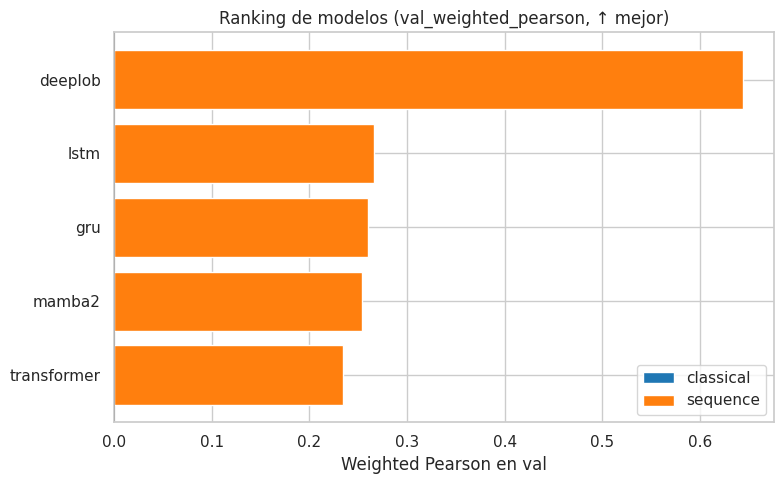

In [22]:
# Barplot ordenado.
fig, ax = plt.subplots(figsize=(8, 5))
palette = {"classical": "tab:blue", "sequence": "tab:orange"}
colors = [palette[k] for k in results_df["kind"]]
ax.barh(results_df["model"][::-1], results_df["val_weighted_pearson"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Weighted Pearson en val")
ax.set_title("Ranking de modelos (val_weighted_pearson, ↑ mejor)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=palette[k], label=k) for k in palette])
fig.tight_layout()
plt.show()

Mejor modelo: deeplob  (val_weighted_pearson = +0.6435)


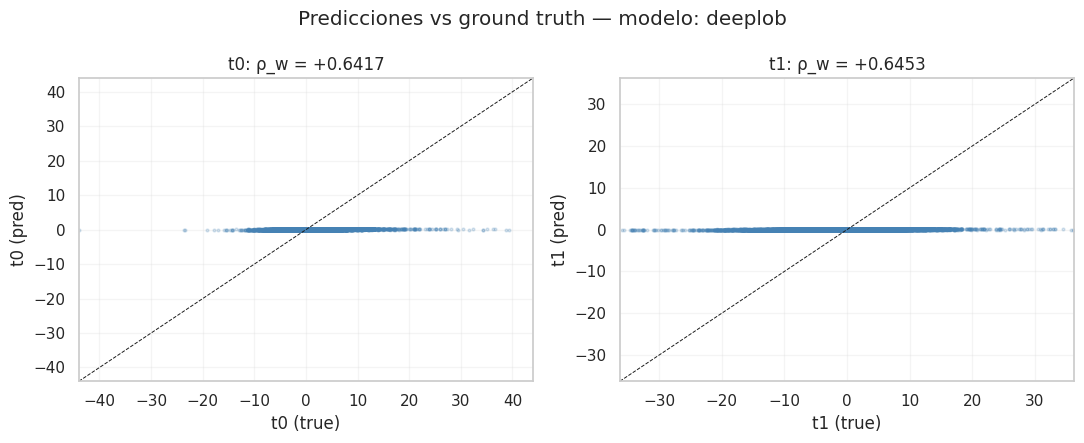

In [23]:
# Diagnóstico del mejor modelo: scatter pred vs true por target.
# Los val_eval (objetos pequeños — solo predicciones + ids) los guardamos en este dict
# para no tener que recomputar; los grandes (modelos, dataframes) ya están liberados o en disco.
all_evals = {}
candidates = [
    ("gru", gru_eval), ("lstm", lstm_eval), ("transformer", tfm_eval),
    ("deeplob", deeplob_eval), ("mamba2", mamba_eval),
]
if not SKIP_CLASSICAL:
    candidates += [("linear", linear_eval), ("ridge", ridge_eval), ("lightgbm", lgb_eval)]
    if not SKIP_RF and 'rf_eval' in dir() and rf_eval is not None:
        candidates.append(("random_forest", rf_eval))
for k, v in candidates:
    if v is not None:
        all_evals[k] = v

best_row = results_df.iloc[0]
best_name = best_row["model"]
best_kind = best_row["kind"]
best_eval = all_evals[best_name]
print(f"Mejor modelo: {best_name}  (val_weighted_pearson = {best_row['val_weighted_pearson']:+.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, j, name in zip(axes, [0, 1], TARGET_COLS):
    ax.scatter(best_eval.targets[:, j], best_eval.predictions[:, j], s=4, alpha=0.2, color="steelblue")
    lim = max(np.abs(best_eval.targets[:, j]).max(), np.abs(best_eval.predictions[:, j]).max(), 1.0)
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.7)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"{name} (true)"); ax.set_ylabel(f"{name} (pred)")
    ax.set_title(f"{name}: ρ_w = {best_eval.metrics['per_target'][name]:+.4f}")
    ax.grid(alpha=0.2)
fig.suptitle(f"Predicciones vs ground truth — modelo: {best_name}")
fig.tight_layout()
plt.show()

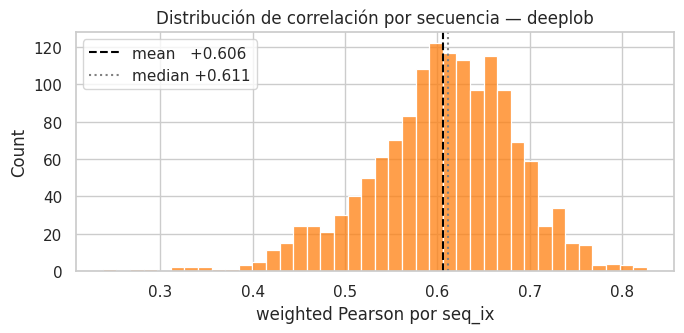

In [24]:
# Distribución de la correlación weighted Pearson por secuencia (mide robustez).
seq_corr = pd.Series(best_eval.per_sequence_corr)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(seq_corr, bins=40, ax=ax, color="tab:orange")
ax.axvline(seq_corr.mean(),   color="black", linestyle="--", label=f"mean   {seq_corr.mean():+.3f}")
ax.axvline(seq_corr.median(), color="gray",  linestyle=":",  label=f"median {seq_corr.median():+.3f}")
ax.set_xlabel("weighted Pearson por seq_ix")
ax.legend()
ax.set_title(f"Distribución de correlación por secuencia — {best_name}")
fig.tight_layout()
plt.show()

## 9 · Selección del modelo final

El mejor modelo (mayor `val_weighted_pearson`) ya está persistido por
`run_classical` / `run_sequence` en `experiments/<best>/<run_id>/`. Aquí solo
imprimimos su ubicación y muestramos los artefactos generados para que sepas
exactamente dónde encontrar `model.{pt,joblib}`, `metrics.json`, `predictions.parquet`
y los plots.

In [ ]:
best_run_dir = Path(best_row["run_dir"])
artefacts = sorted(p.relative_to(best_run_dir) for p in best_run_dir.rglob("*") if p.is_file())

print(f"Modelo elegido:   {best_name}  ({best_kind})")
print(f"Run directory:    {best_run_dir}")
print(f"val_weighted_pearson = {best_row['val_weighted_pearson']:+.4f}")
print()
print("Artefactos persistidos:")
for p in artefacts:
    print(f"  - {p}")

In [ ]:
# Snapshot de la tabla acumulada (también está en experiments/notebook_results.csv).
print(f"results CSV: {NOTEBOOK_RESULTS_CSV}")
print()
results_df.to_string(index=False)

## 10 · Conclusiones y próximos pasos

### Lecciones de las iteraciones

* **Clásicos**: en problemas de microestructura una regresión lineal sobre features
  ingenieradas suele ser un piso fuerte. LightGBM con `sample_weight = |y|` y early stop
  en weighted Pearson aprovecha bien la no-linealidad.
* **RNN básicos (GRU/LSTM)**: aprenden el régimen temporal sin necesidad de ventanas,
  pero son sensibles al learning rate y al warm-up.
* **Transformer causal**: requiere más datos / epochs para empezar a generalizar; en
  modo rápido suele quedar por debajo de los RNN.
* **DeepLOB**: arquitectura específica para LOB; en regresión hay que cuidar que la
  interpolación temporal no diluya la señal del último step.
* **Mamba-2**: con kernels nativos CUDA escala lineal en T = 1000 sin penalización
  de memoria, lo que lo hace especialmente atractivo para esta longitud.

### Próximos pasos

* **TLOB / MLPLOB** (Berti & Kasneci 2025) — actual SOTA en FI-2010; arquitecturas
  pequeñas, fácil de portar al `models.sequence/` y registrar.
* **Supervised-AE + Multi-task MLP** — receta ganadora de Jane Street 2021, ideal para
  ensemblar con LightGBM y los RNN.
* **Ensembles** — rank-then-average de los top-3 suele aportar +5–15 % de correlación.
* **Tuning**: una sweep ligera con Optuna sobre el LightGBM y un *learning-rate finder*
  para los DL es lo siguiente más rentable.

### Reproducibilidad

Todos los runs producen un directorio en `experiments/<model>/<run_id>/` con
`config.yaml`, `metrics.json`, `predictions.parquet`, `scatter.png`,
`per_seq_corr.png` y (para los DL) `train_history.{csv,png}`. La tabla agregada
de todos los runs se mantiene en `experiments/notebook_results.csv` y sobrevive
a reinicios del kernel. Cualquier modelo nuevo (subclase con
`@register_model("name", kind=…)` + un YAML) se integra al pipeline sin tocar
nada más; ver `README.md` ➝ *Adding a new model*.